# Approche A : LSTM pour prediction de violations SLA (M/M/1)

**Objectif** : Predire si le SLA d'un slice 5G sera viole dans les 15 prochaines secondes,
a partir de metriques de trafic reel + latence simulee (modele M/M/1).

**Dataset** : `slice_sla_dataset` (111 040 lignes, 7 jours, 4 slices)

**Modele** : LSTM (Long Short-Term Memory) avec fenetre de 30 secondes

## 1. Installation des dependances

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'torch', 'scikit-learn', 'matplotlib', 'seaborn'])

0

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
print(f'NumPy   : {np.__version__}')
print(f'Pandas  : {pd.__version__}')

PyTorch : 2.10.0+cpu
Device  : cpu
NumPy   : 2.4.1
Pandas  : 3.0.0


## 2. Chargement et exploration des donnees

In [3]:
import glob
import os

# Detecter l'environnement (Docker ou local Windows)
if os.path.exists('/home/work/output/slice_sla_dataset'):
    base_dir = '/home/work/output/slice_sla_dataset'
else:
    # Local Windows : chemin relatif depuis le notebook
    base_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'output', 'slice_sla_dataset')
    if not os.path.exists(base_dir):
        # Fallback : chemin absolu Windows
        base_dir = r'C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\output\slice_sla_dataset'

csv_files = glob.glob(os.path.join(base_dir, 'part-*.csv'))
assert len(csv_files) > 0, f'Aucun CSV trouve dans {base_dir}'

csv_path = csv_files[0]
print(f'Fichier : {csv_path}')

df = pd.read_csv(csv_path)
print(f'Shape : {df.shape}')
df.head()

Fichier : C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\output\slice_sla_dataset\part-00000-94ed05f1-4ecf-4ffd-9ecc-2a72579b207b-c000.csv
Shape : (111040, 13)


,Time_Sec,Slice Type,Slice_Throughput_Mbps,Slice_Jitter_ms,Slice_Packet_Loss_pct,Slice_Network_Load_pct,Slice_Latency_ms,SLA_Throughput_Min_Mbps,SLA_PacketLoss_Max_pct,SLA_Latency_Max_ms,SLA_OK,SLA_OK_in_15s,SLA_Violated_in_15s
0,2022-09-27T13:16:17.000Z,eMBB,1.935568,3.095606,0.0,3.869088,5.100671,10.0,1.0,50.0,False,False,1
1,2022-09-27T13:16:18.000Z,eMBB,1.651624,4.462615,0.0,3.301200,5.085399,10.0,1.0,50.0,False,False,1
2,2022-09-27T13:16:19.000Z,eMBB,1.407496,6.170375,0.0,2.812944,5.072410,10.0,1.0,50.0,False,False,1
3,2022-09-27T13:16:20.000Z,eMBB,1.619664,6.434793,0.0,3.237280,5.083691,10.0,1.0,50.0,False,False,1
4,2022-09-27T13:16:21.000Z,eMBB,1.393488,4.024315,0.0,2.785952,5.071670,10.0,1.0,50.0,False,False,1


In [4]:
# Repertoire de sortie (adapte Docker ou local)
if os.path.exists('/home/work/output'):
    OUTPUT_DIR = '/home/work/output'
else:
    OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'output')
    if not os.path.exists(OUTPUT_DIR):
        OUTPUT_DIR = r'C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\output'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Repertoire de sortie : {OUTPUT_DIR}')

df.info()
print('\n--- Valeurs manquantes ---')
print(df.isnull().sum())

Repertoire de sortie : C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\output
<class 'pandas.DataFrame'>
RangeIndex: 111040 entries, 0 to 111039
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Time_Sec                 111040 non-null  str    
 1   Slice Type               111040 non-null  str    
 2   Slice_Throughput_Mbps    111040 non-null  float64
 3   Slice_Jitter_ms          111040 non-null  float64
 4   Slice_Packet_Loss_pct    111040 non-null  float64
 5   Slice_Network_Load_pct   111040 non-null  float64
 6   Slice_Latency_ms         111040 non-null  float64
 7   SLA_Throughput_Min_Mbps  111040 non-null  float64
 8   SLA_PacketLoss_Max_pct   111040 non-null  float64
 9   SLA_Latency_Max_ms       111040 non-null  float64
 10  SLA_OK                   111040 non-null  bool   
 11  SLA_OK_in_15s            111040 non-null  bool   
 12 

In [5]:
# Distribution du label par slice
print('=== Distribution globale du label ===')
print(df['SLA_Violated_in_15s'].value_counts())
print(f'\nRatio violations : {df["SLA_Violated_in_15s"].mean():.2%}')

print('\n=== Distribution par Slice Type ===')
ct = pd.crosstab(df['Slice Type'], df['SLA_Violated_in_15s'], margins=True)
ct['Violation %'] = (ct[1] / ct['All'] * 100).round(2)
print(ct)

=== Distribution globale du label ===
SLA_Violated_in_15s
0    73047
1    37993
Name: count, dtype: int64

Ratio violations : 34.22%

=== Distribution par Slice Type ===
SLA_Violated_in_15s      0      1     All  Violation %
Slice Type                                            
Best Effort              0  22743   22743       100.00
URLLC                44012     15   44027         0.03
eMBB                 29031  14984   44015        34.04
mMTC                     4    251     255        98.43
All                  73047  37993  111040        34.22


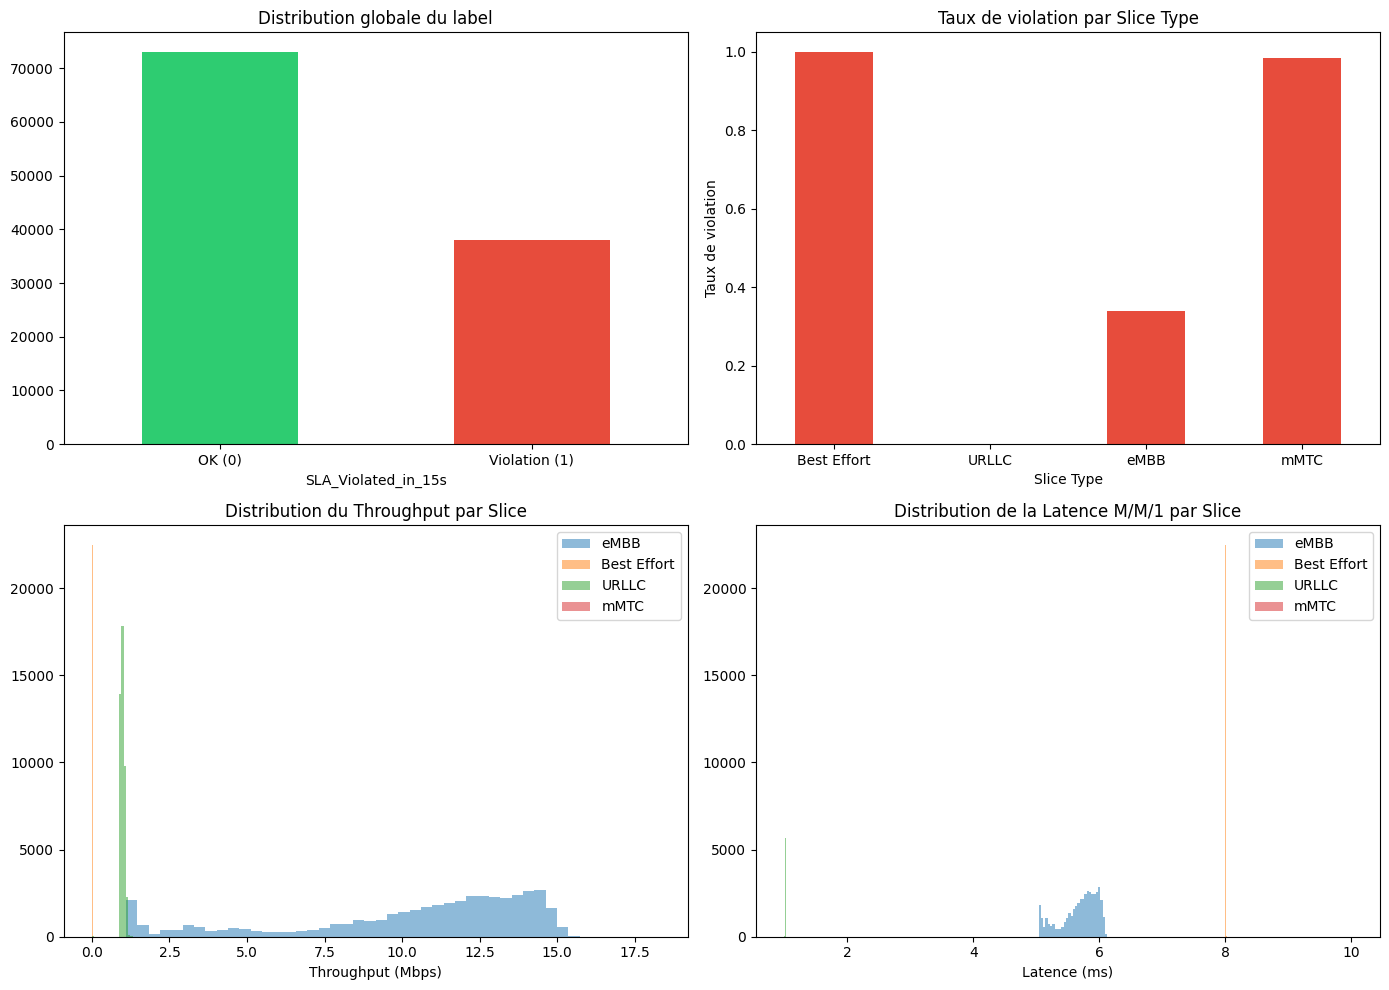

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution du label
df['SLA_Violated_in_15s'].value_counts().plot.bar(ax=axes[0, 0], color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Distribution globale du label')
axes[0, 0].set_xticklabels(['OK (0)', 'Violation (1)'], rotation=0)

# Violations par slice
df.groupby('Slice Type')['SLA_Violated_in_15s'].mean().plot.bar(ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Taux de violation par Slice Type')
axes[0, 1].set_ylabel('Taux de violation')
axes[0, 1].tick_params(axis='x', rotation=0)

# Distribution du throughput par slice
for st in df['Slice Type'].unique():
    subset = df[df['Slice Type'] == st]
    axes[1, 0].hist(subset['Slice_Throughput_Mbps'], bins=50, alpha=0.5, label=st)
axes[1, 0].set_title('Distribution du Throughput par Slice')
axes[1, 0].set_xlabel('Throughput (Mbps)')
axes[1, 0].legend()

# Distribution de la latence par slice
for st in df['Slice Type'].unique():
    subset = df[df['Slice Type'] == st]
    axes[1, 1].hist(subset['Slice_Latency_ms'], bins=50, alpha=0.5, label=st)
axes[1, 1].set_title('Distribution de la Latence M/M/1 par Slice')
axes[1, 1].set_xlabel('Latence (ms)')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exploration_distributions.png'), dpi=150)
plt.show()

In [7]:
# Stats descriptives des features numeriques
numeric_cols = ['Slice_Throughput_Mbps', 'Slice_Jitter_ms', 'Slice_Packet_Loss_pct',
                'Slice_Network_Load_pct', 'Slice_Latency_ms']
df[numeric_cols].describe().round(4)

,Slice_Throughput_Mbps,Slice_Jitter_ms,Slice_Packet_Loss_pct,Slice_Network_Load_pct,Slice_Latency_ms
count,111040.0000,1.110400e+05,111040.0,111040.0000,111040.0000
mean,4.5071,2.841017e+03,0.0,11.4020,4.3196
std,5.3695,4.513101e+05,0.0,9.5037,2.8165
min,0.0003,0.000000e+00,0.0,0.0010,1.0001
25%,0.9222,1.861200e+00,0.0,7.0303,1.0220
50%,1.0269,4.021100e+00,0.0,7.9920,5.5366
75%,10.3372,7.831200e+00,0.0,20.6732,5.9996
max,18.2920,9.105623e+07,0.0,36.5820,10.0112


## 3. Preprocessing

Problemes identifies :
1. `Slice_Packet_Loss_pct` = 0 partout (zero variance) -> suppression
2. `Slice_Jitter_ms` a des outliers extremes (max 91M ms) -> capping P99
3. Best Effort (100% violations) et mMTC (98%) sont quasi-deterministes
4. URLLC n'a que 0.03% de violations -> pas assez pour un LSTM

**Strategie** : entrainer sur les 4 slices (le modele apprend a distinguer),
mais evaluer surtout sur eMBB (le seul avec une distribution interessante).

In [8]:
# --- 3.1 Suppression de Packet Loss (zero variance) ---
print(f'Packet Loss - valeurs uniques : {df["Slice_Packet_Loss_pct"].nunique()}')
print(f'Packet Loss - max : {df["Slice_Packet_Loss_pct"].max()}')
df = df.drop(columns=['Slice_Packet_Loss_pct'])
print('-> Slice_Packet_Loss_pct supprime')

Packet Loss - valeurs uniques : 1
Packet Loss - max : 0.0
-> Slice_Packet_Loss_pct supprime


In [9]:
# --- 3.2 Capping du Jitter au percentile 99 ---
p99_jitter = df['Slice_Jitter_ms'].quantile(0.99)
print(f'Jitter P99 : {p99_jitter:.2f} ms')
print(f'Jitter max avant : {df["Slice_Jitter_ms"].max():.2f} ms')

df['Slice_Jitter_ms'] = df['Slice_Jitter_ms'].clip(upper=p99_jitter)
print(f'Jitter max apres : {df["Slice_Jitter_ms"].max():.2f} ms')

Jitter P99 : 16.37 ms
Jitter max avant : 91056228.23 ms
Jitter max apres : 16.37 ms


In [10]:
# --- 3.3 Parsing du timestamp et tri ---
df['Time_Sec'] = pd.to_datetime(df['Time_Sec'])
df = df.sort_values(['Slice Type', 'Time_Sec']).reset_index(drop=True)

print(f'Plage temporelle : {df["Time_Sec"].min()} -> {df["Time_Sec"].max()}')
print(f'Duree : {(df["Time_Sec"].max() - df["Time_Sec"].min()).total_seconds() / 3600:.1f} heures')

Plage temporelle : 2022-09-27 13:08:31+00:00 -> 2022-10-04 16:14:22+00:00
Duree : 171.1 heures


In [11]:
# --- 3.4 Feature Engineering : moyennes glissantes et tendances ---
# On calcule par slice pour eviter le melange inter-slices

feature_cols = ['Slice_Throughput_Mbps', 'Slice_Jitter_ms',
                'Slice_Network_Load_pct', 'Slice_Latency_ms']

for col in feature_cols:
    # Moyenne glissante 5s
    df[f'{col}_ma5'] = df.groupby('Slice Type')[col].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )
    # Moyenne glissante 10s
    df[f'{col}_ma10'] = df.groupby('Slice Type')[col].transform(
        lambda x: x.rolling(10, min_periods=1).mean()
    )
    # Derivee (variation par rapport a t-1)
    df[f'{col}_diff'] = df.groupby('Slice Type')[col].transform(
        lambda x: x.diff().fillna(0)
    )

print(f'Nombre de features apres engineering : {len([c for c in df.columns if c not in ["Time_Sec", "Slice Type", "SLA_OK", "SLA_OK_in_15s", "SLA_Violated_in_15s"]])}')
print(f'Nouvelles colonnes : {[c for c in df.columns if "_ma" in c or "_diff" in c]}')

Nombre de features apres engineering : 19
Nouvelles colonnes : ['Slice_Throughput_Mbps_ma5', 'Slice_Throughput_Mbps_ma10', 'Slice_Throughput_Mbps_diff', 'Slice_Jitter_ms_ma5', 'Slice_Jitter_ms_ma10', 'Slice_Jitter_ms_diff', 'Slice_Network_Load_pct_ma5', 'Slice_Network_Load_pct_ma10', 'Slice_Network_Load_pct_diff', 'Slice_Latency_ms_ma5', 'Slice_Latency_ms_ma10', 'Slice_Latency_ms_diff']


In [12]:
# --- 3.5 Encoding du Slice Type ---
slice_dummies = pd.get_dummies(df['Slice Type'], prefix='slice')
df = pd.concat([df, slice_dummies], axis=1)

print('Colonnes one-hot :', list(slice_dummies.columns))

Colonnes one-hot : ['slice_Best Effort', 'slice_URLLC', 'slice_eMBB', 'slice_mMTC']


In [13]:
# --- 3.6 Selection des features finales ---
# Features d'entree pour le LSTM
input_features = (
    feature_cols +
    [f'{c}_ma5' for c in feature_cols] +
    [f'{c}_ma10' for c in feature_cols] +
    [f'{c}_diff' for c in feature_cols] +
    list(slice_dummies.columns)
)

target_col = 'SLA_Violated_in_15s'

print(f'Features ({len(input_features)}) :')
for i, f in enumerate(input_features):
    print(f'  {i+1:2d}. {f}')

Features (20) :
   1. Slice_Throughput_Mbps
   2. Slice_Jitter_ms
   3. Slice_Network_Load_pct
   4. Slice_Latency_ms
   5. Slice_Throughput_Mbps_ma5
   6. Slice_Jitter_ms_ma5
   7. Slice_Network_Load_pct_ma5
   8. Slice_Latency_ms_ma5
   9. Slice_Throughput_Mbps_ma10
  10. Slice_Jitter_ms_ma10
  11. Slice_Network_Load_pct_ma10
  12. Slice_Latency_ms_ma10
  13. Slice_Throughput_Mbps_diff
  14. Slice_Jitter_ms_diff
  15. Slice_Network_Load_pct_diff
  16. Slice_Latency_ms_diff
  17. slice_Best Effort
  18. slice_URLLC
  19. slice_eMBB
  20. slice_mMTC


In [14]:
# --- 3.7 Normalisation MinMaxScaler ---
# On fit le scaler UNIQUEMENT sur le train (split temporel d'abord)

# Split temporel : 80% train, 20% test
split_time = df['Time_Sec'].quantile(0.8)
print(f'Split temporel a : {split_time}')
print(f'Train : {df["Time_Sec"].min()} -> {split_time}')
print(f'Test  : {split_time} -> {df["Time_Sec"].max()}')

train_mask = df['Time_Sec'] <= split_time
test_mask = df['Time_Sec'] > split_time

print(f'\nTrain : {train_mask.sum()} lignes ({train_mask.mean():.1%})')
print(f'Test  : {test_mask.sum()} lignes ({test_mask.mean():.1%})')

# Convertir les colonnes one-hot en float (elles sont bool apres get_dummies)
for col in slice_dummies.columns:
    df[col] = df[col].astype(float)

# Normaliser seulement les features continues (les one-hot sont deja 0/1)
continuous_features = [f for f in input_features if f not in slice_dummies.columns]

scaler = MinMaxScaler()
df.loc[train_mask, continuous_features] = scaler.fit_transform(df.loc[train_mask, continuous_features])
df.loc[test_mask, continuous_features] = scaler.transform(df.loc[test_mask, continuous_features])

print(f'\nNormalisation terminee (MinMaxScaler sur {len(continuous_features)} features continues)')
print(f'Features one-hot non scalees : {list(slice_dummies.columns)}')

Split temporel a : 2022-10-04 13:37:51+00:00
Train : 2022-09-27 13:08:31+00:00 -> 2022-10-04 13:37:51+00:00
Test  : 2022-10-04 13:37:51+00:00 -> 2022-10-04 16:14:22+00:00

Train : 88833 lignes (80.0%)
Test  : 22207 lignes (20.0%)

Normalisation terminee (MinMaxScaler sur 16 features continues)
Features one-hot non scalees : ['slice_Best Effort', 'slice_URLLC', 'slice_eMBB', 'slice_mMTC']


## 4. Construction des sequences LSTM

Le LSTM a besoin de sequences temporelles :
- **Lookback** = 30 secondes d'historique
- **Input** : (batch, 30, N_features)
- **Output** : (batch, 1) = SLA_Violated_in_15s

Les sequences sont construites **par slice** pour eviter de melanger
des donnees de slices differents dans une meme fenetre.

In [15]:
LOOKBACK = 30  # 30 secondes d'historique

def create_sequences(data, features, target, lookback):
    """Cree des sequences pour le LSTM a partir d'un DataFrame trie par temps."""
    X, y = [], []
    values = data[features].values
    labels = data[target].values

    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i])
        y.append(labels[i])

    return np.array(X), np.array(y)

# Construction par slice puis concatenation
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

for slice_type in df['Slice Type'].unique():
    slice_data = df[df['Slice Type'] == slice_type].sort_values('Time_Sec')

    # Split train/test pour ce slice
    train_slice = slice_data[slice_data['Time_Sec'] <= split_time]
    test_slice = slice_data[slice_data['Time_Sec'] > split_time]

    if len(train_slice) > LOOKBACK:
        X_tr, y_tr = create_sequences(train_slice, input_features, target_col, LOOKBACK)
        X_train_list.append(X_tr)
        y_train_list.append(y_tr)
        print(f'  {slice_type:12s} train : {X_tr.shape[0]:6d} sequences'
              f' | violations : {y_tr.mean():.2%}')

    if len(test_slice) > LOOKBACK:
        X_te, y_te = create_sequences(test_slice, input_features, target_col, LOOKBACK)
        X_test_list.append(X_te)
        y_test_list.append(y_te)
        print(f'  {slice_type:12s} test  : {X_te.shape[0]:6d} sequences'
              f' | violations : {y_te.mean():.2%}')

X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)
X_test = np.concatenate(X_test_list)
y_test = np.concatenate(y_test_list)

print(f'\nX_train : {X_train.shape}  (samples, timesteps, features)')
print(f'y_train : {y_train.shape}  | violations : {y_train.mean():.2%}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}   | violations : {y_test.mean():.2%}')

  Best Effort  train :  18211 sequences | violations : 100.00%
  Best Effort  test  :   4472 sequences | violations : 100.00%
  URLLC        train :  35144 sequences | violations : 0.04%
  URLLC        test  :   8823 sequences | violations : 0.01%
  eMBB         train :  35133 sequences | violations : 38.25%
  eMBB         test  :   8822 sequences | violations : 17.15%
  mMTC         train :    225 sequences | violations : 98.67%

X_train : (88713, 30, 20)  (samples, timesteps, features)
y_train : (88713,)  | violations : 35.94%
X_test  : (22117, 30, 20)
y_test  : (22117,)   | violations : 27.07%


## 5. Modele LSTM (PyTorch)

Architecture :
```
Input (30, N_features)
  -> LSTM(64, num_layers=1)
  -> Dropout(0.3)
  -> LSTM(32, num_layers=1)
  -> Dropout(0.3)
  -> Linear(32, 16) + ReLU
  -> Linear(16, 1)
```

`BCEWithLogitsLoss` avec `pos_weight` pour gerer le desequilibre.

In [16]:
# --- Dataset PyTorch ---
class SLADataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --- Modele LSTM ---
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, hidden1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out[:, -1, :])  # dernier pas de temps
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out.squeeze(-1)

n_features = X_train.shape[2]
model = LSTMModel(n_features).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parametres : {total_params:,}')

LSTMModel(
  (lstm1): LSTM(20, 64, batch_first=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Total parametres : 35,105


In [17]:
# Class weights : pos_weight pour BCEWithLogitsLoss
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)

print(f'Classe 0 (OK)        : {n_neg:,.0f} samples')
print(f'Classe 1 (Violation) : {n_pos:,.0f} samples')
print(f'pos_weight           : {pos_weight.item():.3f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# DataLoaders
BATCH_SIZE = 256

train_dataset = SLADataset(X_train, y_train)
# Split train -> train_fit (80%) + val (20%)
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_fit, val_set = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_fit, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = SLADataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'\nTrain fit : {train_size:,} samples')
print(f'Validation: {val_size:,} samples')
print(f'Test      : {len(test_dataset):,} samples')

Classe 0 (OK)        : 56,829 samples
Classe 1 (Violation) : 31,884 samples
pos_weight           : 1.782

Train fit : 70,971 samples
Validation: 17,742 samples
Test      : 22,117 samples


## 6. Entrainement

In [18]:
EPOCHS = 50
PATIENCE = 5

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0
best_state = None

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(y_batch)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    train_loss /= total
    train_acc = correct / total

    # --- Validation ---
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item() * len(y_batch)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)

    val_loss /= total
    val_acc = correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict().copy()
        patience_counter = 0
        marker = ' *'
    else:
        patience_counter += 1
        marker = ''

    print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping a l\'epoch {epoch+1}')
        break

# Restaurer les meilleurs poids
model.load_state_dict(best_state)
print(f'\nMeilleurs poids restaures (val_loss = {best_val_loss:.4f})')

Epoch   1/50 | Train Loss: 0.3786 Acc: 0.8805 | Val Loss: 0.2792 Acc: 0.9003 *
Epoch   2/50 | Train Loss: 0.2787 Acc: 0.8978 | Val Loss: 0.2789 Acc: 0.9031 *
Epoch   3/50 | Train Loss: 0.2766 Acc: 0.8988 | Val Loss: 0.2777 Acc: 0.9006 *
Epoch   4/50 | Train Loss: 0.2755 Acc: 0.8988 | Val Loss: 0.2779 Acc: 0.9034
Epoch   5/50 | Train Loss: 0.2742 Acc: 0.8984 | Val Loss: 0.2714 Acc: 0.8997 *
Epoch   6/50 | Train Loss: 0.2729 Acc: 0.8979 | Val Loss: 0.2710 Acc: 0.8974 *
Epoch   7/50 | Train Loss: 0.2722 Acc: 0.8983 | Val Loss: 0.2730 Acc: 0.8974
Epoch   8/50 | Train Loss: 0.2723 Acc: 0.8977 | Val Loss: 0.2720 Acc: 0.9005
Epoch   9/50 | Train Loss: 0.2712 Acc: 0.8992 | Val Loss: 0.2749 Acc: 0.9024
Epoch  10/50 | Train Loss: 0.2716 Acc: 0.8985 | Val Loss: 0.2710 Acc: 0.9020 *
Epoch  11/50 | Train Loss: 0.2698 Acc: 0.8989 | Val Loss: 0.2696 Acc: 0.8987 *
Epoch  12/50 | Train Loss: 0.2690 Acc: 0.8987 | Val Loss: 0.2697 Acc: 0.9016
Epoch  13/50 | Train Loss: 0.2685 Acc: 0.8991 | Val Loss: 0.27

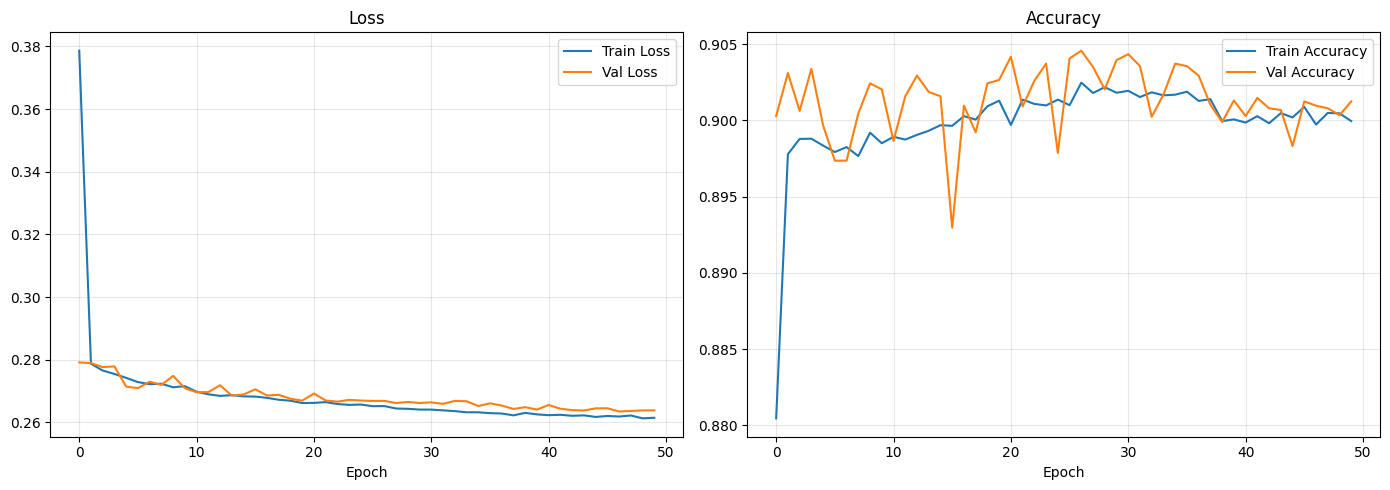

In [19]:
# Courbes d'entrainement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['val_acc'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 7. Evaluation

In [20]:
# Predictions sur le test set
model.eval()
all_logits = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        all_logits.append(logits.cpu())

y_pred_proba = torch.sigmoid(torch.cat(all_logits)).numpy()
y_pred = (y_pred_proba >= 0.5).astype(int)

print('=== Classification Report (global) ===')
print(classification_report(y_test, y_pred, target_names=['OK', 'Violation']))

print(f'F1-score      : {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC       : {roc_auc_score(y_test, y_pred_proba):.4f}')

=== Classification Report (global) ===
              precision    recall  f1-score   support

          OK       0.94      0.95      0.95     16131
   Violation       0.87      0.85      0.86      5986

    accuracy                           0.93     22117
   macro avg       0.91      0.90      0.90     22117
weighted avg       0.93      0.93      0.93     22117

F1-score      : 0.8606
AUC-ROC       : 0.9710


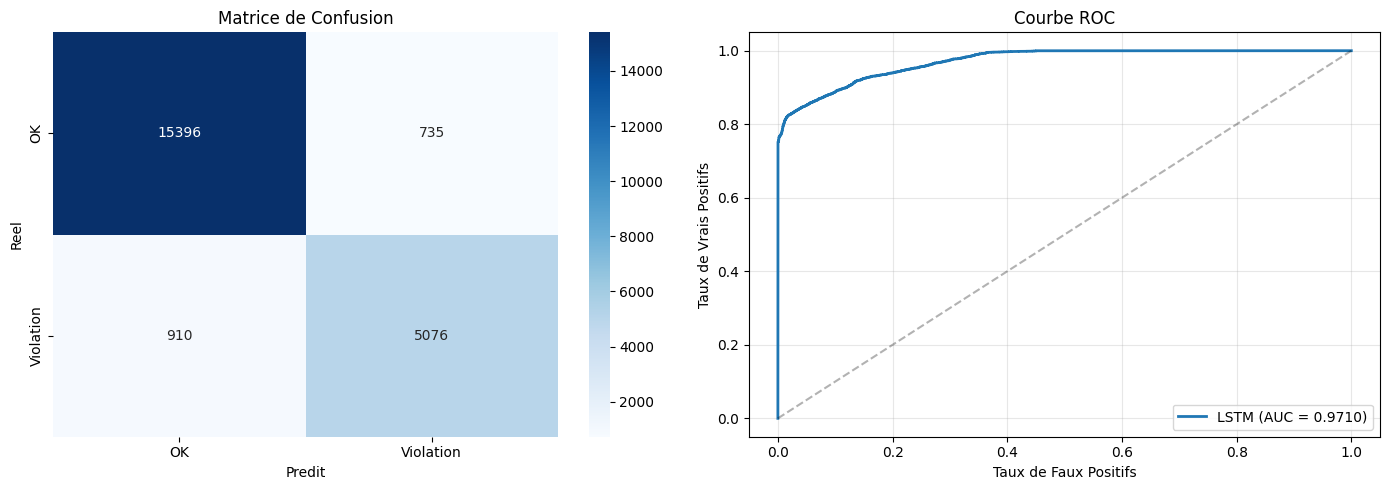

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['OK', 'Violation'], yticklabels=['OK', 'Violation'])
axes[0].set_title('Matrice de Confusion')
axes[0].set_ylabel('Reel')
axes[0].set_xlabel('Predit')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'LSTM (AUC = {auc:.4f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('Courbe ROC')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'evaluation_results.png'), dpi=150)
plt.show()

In [22]:
# --- Evaluation par Slice Type ---
# Reconstruire les labels de slice pour le test set
# On recree les indices en parcourant les slices dans le meme ordre

slice_labels_test = []
for slice_type in df['Slice Type'].unique():
    slice_data = df[df['Slice Type'] == slice_type].sort_values('Time_Sec')
    test_slice = slice_data[slice_data['Time_Sec'] > split_time]
    if len(test_slice) > LOOKBACK:
        n_sequences = len(test_slice) - LOOKBACK
        slice_labels_test.extend([slice_type] * n_sequences)

slice_labels_test = np.array(slice_labels_test)

print('=== Resultats par Slice Type ===')
print(f'{"Slice":>14s} | {"F1":>6s} | {"Precision":>9s} | {"Recall":>6s} | {"AUC":>6s} | {"Support":>7s}')
print('-' * 65)

results_per_slice = {}
for st in sorted(df['Slice Type'].unique()):
    mask = slice_labels_test == st
    if mask.sum() == 0:
        continue
    yt = y_test[mask]
    yp = y_pred[mask]
    ypp = y_pred_proba[mask]

    f1 = f1_score(yt, yp, zero_division=0)
    # Precision et recall manuels
    tp = ((yp == 1) & (yt == 1)).sum()
    fp = ((yp == 1) & (yt == 0)).sum()
    fn = ((yp == 0) & (yt == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0

    # AUC seulement si les deux classes sont presentes
    if len(np.unique(yt)) > 1:
        auc_val = roc_auc_score(yt, ypp)
    else:
        auc_val = float('nan')

    results_per_slice[st] = {'F1': f1, 'Precision': prec, 'Recall': rec, 'AUC': auc_val}
    print(f'{st:>14s} | {f1:>6.4f} | {prec:>9.4f} | {rec:>6.4f} | {auc_val:>6.4f} | {mask.sum():>7d}')

print(f'\n{"GLOBAL":>14s} | {f1_score(y_test, y_pred):>6.4f} | '
      f'{"":>9s} | {"":>6s} | {roc_auc_score(y_test, y_pred_proba):>6.4f} | {len(y_test):>7d}')

=== Resultats par Slice Type ===
         Slice |     F1 | Precision | Recall |    AUC | Support
-----------------------------------------------------------------
   Best Effort | 1.0000 |    1.0000 | 1.0000 |    nan |    4472
         URLLC | 0.0000 |    0.0000 | 0.0000 | 0.6251 |    8823
          eMBB | 0.4236 |    0.4511 | 0.3992 | 0.7475 |    8822

        GLOBAL | 0.8606 |           |        | 0.9710 |   22117


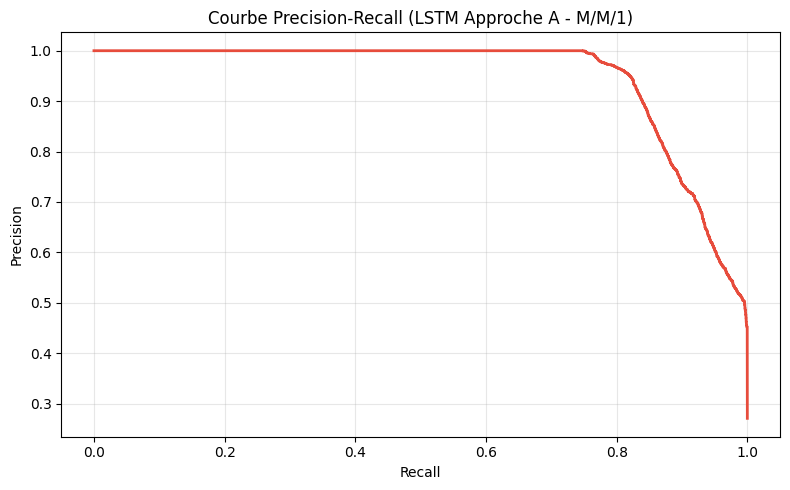

In [23]:
# Courbe Precision-Recall
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall_vals, precision_vals, linewidth=2, color='#e74c3c')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall (LSTM Approche A - M/M/1)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'precision_recall_curve.png'), dpi=150)
plt.show()

## 7b. Cross-Validation Temporelle (TimeSeriesSplit)

Pour evaluer la robustesse du modele, on utilise **TimeSeriesSplit** de scikit-learn.
Contrairement au k-fold classique, ce split respecte l'ordre chronologique :

```
Fold 1 : [Train ████░░░░░░] [Test ██░░░░░░░░]
Fold 2 : [Train ██████░░░░] [Test ██░░░░░░░░]
Fold 3 : [Train ████████░░] [Test ██░░░░░░░░]
Fold 4 : [Train ██████████] [Test ██░░░░░░░░]
Fold 5 : [Train ████████████] [Test ██░░░░░░]
```

Chaque fold utilise **toutes les donnees precedentes** pour entrainer,
et **le bloc suivant** pour tester. Pas de fuite temporelle.

In [24]:
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5
CV_EPOCHS = 30  # moins d'epochs par fold pour limiter le temps
CV_PATIENCE = 4

# On travaille par slice : pour chaque slice, on ordonne par temps
# puis on applique TimeSeriesSplit sur les sequences

# D'abord, reconstruire TOUTES les sequences (sans split train/test)
all_X_per_slice = {}
all_y_per_slice = {}

for slice_type in df['Slice Type'].unique():
    slice_data = df[df['Slice Type'] == slice_type].sort_values('Time_Sec')
    if len(slice_data) > LOOKBACK:
        X_s, y_s = create_sequences(slice_data, input_features, target_col, LOOKBACK)
        all_X_per_slice[slice_type] = X_s
        all_y_per_slice[slice_type] = y_s
        print(f'{slice_type:12s} : {X_s.shape[0]:6d} sequences totales')

# Cross-validation temporelle
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_results = []

for fold_idx, (train_idx, val_idx) in enumerate(
    tscv.split(np.arange(len(df['Time_Sec'].unique())))
):
    print(f'\n{"="*60}')
    print(f'FOLD {fold_idx + 1}/{N_SPLITS}')
    print(f'{"="*60}')

    # Determiner les timestamps de ce fold
    unique_times = np.sort(df['Time_Sec'].unique())
    train_times = set(unique_times[train_idx])
    val_times = set(unique_times[val_idx])

    print(f'Train : {min(train_times)} -> {max(train_times)} ({len(train_times)} timestamps)')
    print(f'Val   : {min(val_times)} -> {max(val_times)} ({len(val_times)} timestamps)')

    # Construire les sequences train/val pour ce fold (par slice)
    X_cv_train_list, y_cv_train_list = [], []
    X_cv_val_list, y_cv_val_list = [], []

    for slice_type in df['Slice Type'].unique():
        slice_data = df[df['Slice Type'] == slice_type].sort_values('Time_Sec')
        train_slice = slice_data[slice_data['Time_Sec'].isin(train_times)]
        val_slice = slice_data[slice_data['Time_Sec'].isin(val_times)]

        if len(train_slice) > LOOKBACK:
            X_tr, y_tr = create_sequences(train_slice, input_features, target_col, LOOKBACK)
            X_cv_train_list.append(X_tr)
            y_cv_train_list.append(y_tr)

        if len(val_slice) > LOOKBACK:
            X_v, y_v = create_sequences(val_slice, input_features, target_col, LOOKBACK)
            X_cv_val_list.append(X_v)
            y_cv_val_list.append(y_v)

    if not X_cv_train_list or not X_cv_val_list:
        print('  -> Pas assez de donnees, fold ignore')
        continue

    X_cv_train = np.concatenate(X_cv_train_list)
    y_cv_train = np.concatenate(y_cv_train_list)
    X_cv_val = np.concatenate(X_cv_val_list)
    y_cv_val = np.concatenate(y_cv_val_list)

    print(f'Train : {X_cv_train.shape[0]:,} sequences | violations : {y_cv_train.mean():.2%}')
    print(f'Val   : {X_cv_val.shape[0]:,} sequences | violations : {y_cv_val.mean():.2%}')

    # Nouveau modele pour chaque fold
    fold_model = LSTMModel(n_features).to(device)

    # pos_weight pour ce fold
    n_pos_fold = y_cv_train.sum()
    n_neg_fold = len(y_cv_train) - n_pos_fold
    pw = torch.FloatTensor([n_neg_fold / max(n_pos_fold, 1)]).to(device)

    fold_criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=0.001)

    fold_train_loader = DataLoader(
        SLADataset(X_cv_train, y_cv_train), batch_size=BATCH_SIZE, shuffle=True
    )
    fold_val_loader = DataLoader(
        SLADataset(X_cv_val, y_cv_val), batch_size=BATCH_SIZE, shuffle=False
    )

    # Entrainement du fold
    best_fold_loss = float('inf')
    best_fold_state = None
    fold_patience = 0

    for epoch in range(CV_EPOCHS):
        fold_model.train()
        t_loss, t_total = 0, 0
        for X_b, y_b in fold_train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            fold_optimizer.zero_grad()
            logits = fold_model(X_b)
            loss = fold_criterion(logits, y_b)
            loss.backward()
            fold_optimizer.step()
            t_loss += loss.item() * len(y_b)
            t_total += len(y_b)

        # Validation
        fold_model.eval()
        v_loss, v_total = 0, 0
        with torch.no_grad():
            for X_b, y_b in fold_val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits = fold_model(X_b)
                loss = fold_criterion(logits, y_b)
                v_loss += loss.item() * len(y_b)
                v_total += len(y_b)

        v_loss /= v_total
        if v_loss < best_fold_loss:
            best_fold_loss = v_loss
            best_fold_state = fold_model.state_dict().copy()
            fold_patience = 0
        else:
            fold_patience += 1

        if fold_patience >= CV_PATIENCE:
            print(f'  Early stopping epoch {epoch+1}')
            break

    # Evaluer le meilleur modele du fold
    fold_model.load_state_dict(best_fold_state)
    fold_model.eval()
    all_logits_cv = []
    with torch.no_grad():
        for X_b, _ in fold_val_loader:
            X_b = X_b.to(device)
            all_logits_cv.append(fold_model(X_b).cpu())

    y_proba_cv = torch.sigmoid(torch.cat(all_logits_cv)).numpy()
    y_pred_cv = (y_proba_cv >= 0.5).astype(int)

    fold_f1 = f1_score(y_cv_val, y_pred_cv, zero_division=0)
    fold_auc = roc_auc_score(y_cv_val, y_proba_cv) if len(np.unique(y_cv_val)) > 1 else float('nan')

    # Precision / Recall
    tp = ((y_pred_cv == 1) & (y_cv_val == 1)).sum()
    fp = ((y_pred_cv == 1) & (y_cv_val == 0)).sum()
    fn = ((y_pred_cv == 0) & (y_cv_val == 1)).sum()
    fold_prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    fold_rec = tp / (tp + fn) if (tp + fn) > 0 else 0

    cv_results.append({
        'fold': fold_idx + 1,
        'f1': fold_f1,
        'auc': fold_auc,
        'precision': fold_prec,
        'recall': fold_rec,
        'train_size': len(X_cv_train),
        'val_size': len(X_cv_val),
        'epochs': epoch + 1
    })

    print(f'  -> F1: {fold_f1:.4f} | AUC: {fold_auc:.4f} | Prec: {fold_prec:.4f} | Rec: {fold_rec:.4f}')

# Resume de la cross-validation
print(f'\n{"="*60}')
print('RESUME CROSS-VALIDATION TEMPORELLE')
print(f'{"="*60}')

cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))

print(f'\n--- Moyennes (+/- ecart-type) ---')
for metric in ['f1', 'auc', 'precision', 'recall']:
    vals = cv_df[metric].dropna()
    print(f'  {metric:>10s} : {vals.mean():.4f} +/- {vals.std():.4f}')

Best Effort  :  22713 sequences totales
URLLC        :  43997 sequences totales
eMBB         :  43985 sequences totales
mMTC         :    225 sequences totales

FOLD 1/5
Train : 2022-09-27 13:08:31+00:00 -> 2022-09-27 18:41:20+00:00 (7382 timestamps)
Val   : 2022-09-27 18:41:21+00:00 -> 2022-09-28 19:53:41+00:00 (7381 timestamps)
Train : 18,306 sequences | violations : 47.87%
Val   : 18,447 sequences | violations : 38.67%
  Early stopping epoch 7
  -> F1: 0.7827 | AUC: 0.9568 | Prec: 0.6429 | Rec: 1.0000

FOLD 2/5
Train : 2022-09-27 13:08:31+00:00 -> 2022-09-28 19:53:41+00:00 (14763 timestamps)
Val   : 2022-09-28 19:53:42+00:00 -> 2022-09-29 14:10:54+00:00 (7381 timestamps)
Train : 36,843 sequences | violations : 43.31%
Val   : 18,427 sequences | violations : 28.87%
  Early stopping epoch 23
  -> F1: 0.8684 | AUC: 0.9721 | Prec: 0.8740 | Rec: 0.8629

FOLD 3/5
Train : 2022-09-27 13:08:31+00:00 -> 2022-09-29 14:10:54+00:00 (22144 timestamps)
Val   : 2022-09-29 14:10:55+00:00 -> 2022-09-3

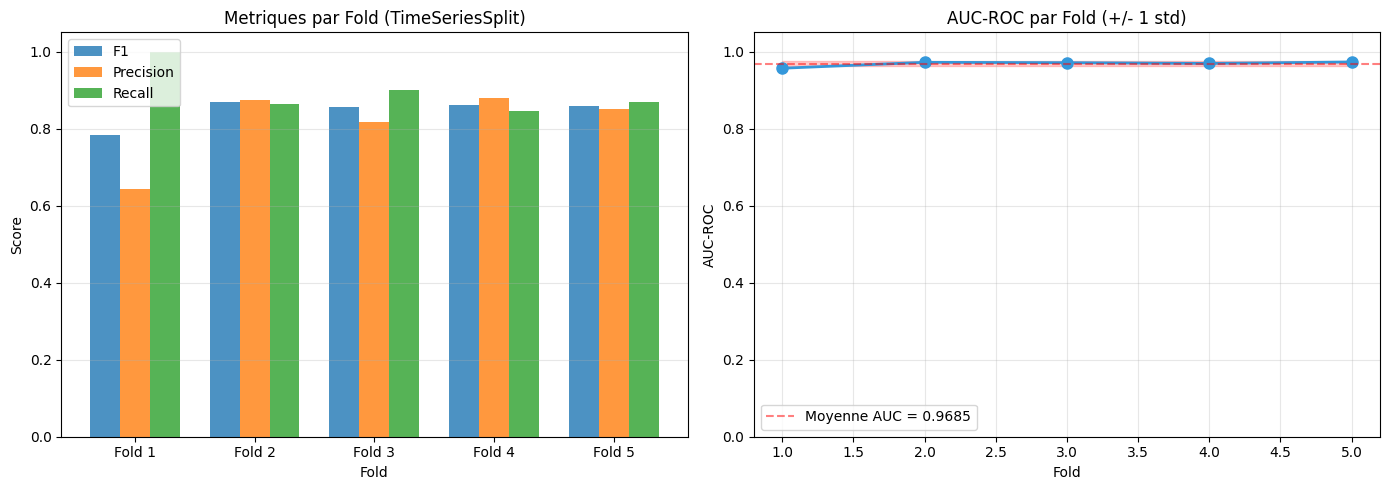


Conclusion : Le modele est stable (std F1 = 0.0356)


In [25]:
# Visualisation des resultats de la cross-validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metriques par fold
metrics = ['f1', 'precision', 'recall']
x = np.arange(len(cv_df))
width = 0.25

for i, metric in enumerate(metrics):
    axes[0].bar(x + i * width, cv_df[metric], width, label=metric.capitalize(), alpha=0.8)

axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metriques par Fold (TimeSeriesSplit)')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([f'Fold {i+1}' for i in range(len(cv_df))])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1.05)

# AUC par fold
axes[1].plot(cv_df['fold'], cv_df['auc'], 'o-', color='#3498db', linewidth=2, markersize=8)
axes[1].axhline(y=cv_df['auc'].mean(), color='red', linestyle='--', alpha=0.5,
                label=f'Moyenne AUC = {cv_df["auc"].mean():.4f}')
axes[1].fill_between(cv_df['fold'],
                     cv_df['auc'].mean() - cv_df['auc'].std(),
                     cv_df['auc'].mean() + cv_df['auc'].std(),
                     alpha=0.2, color='red')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC par Fold (+/- 1 std)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cross_validation_results.png'), dpi=150)
plt.show()

print(f'\nConclusion : Le modele est {"stable" if cv_df["f1"].std() < 0.1 else "instable"} '
      f'(std F1 = {cv_df["f1"].std():.4f})')

## 8. Analyse et sauvegarde

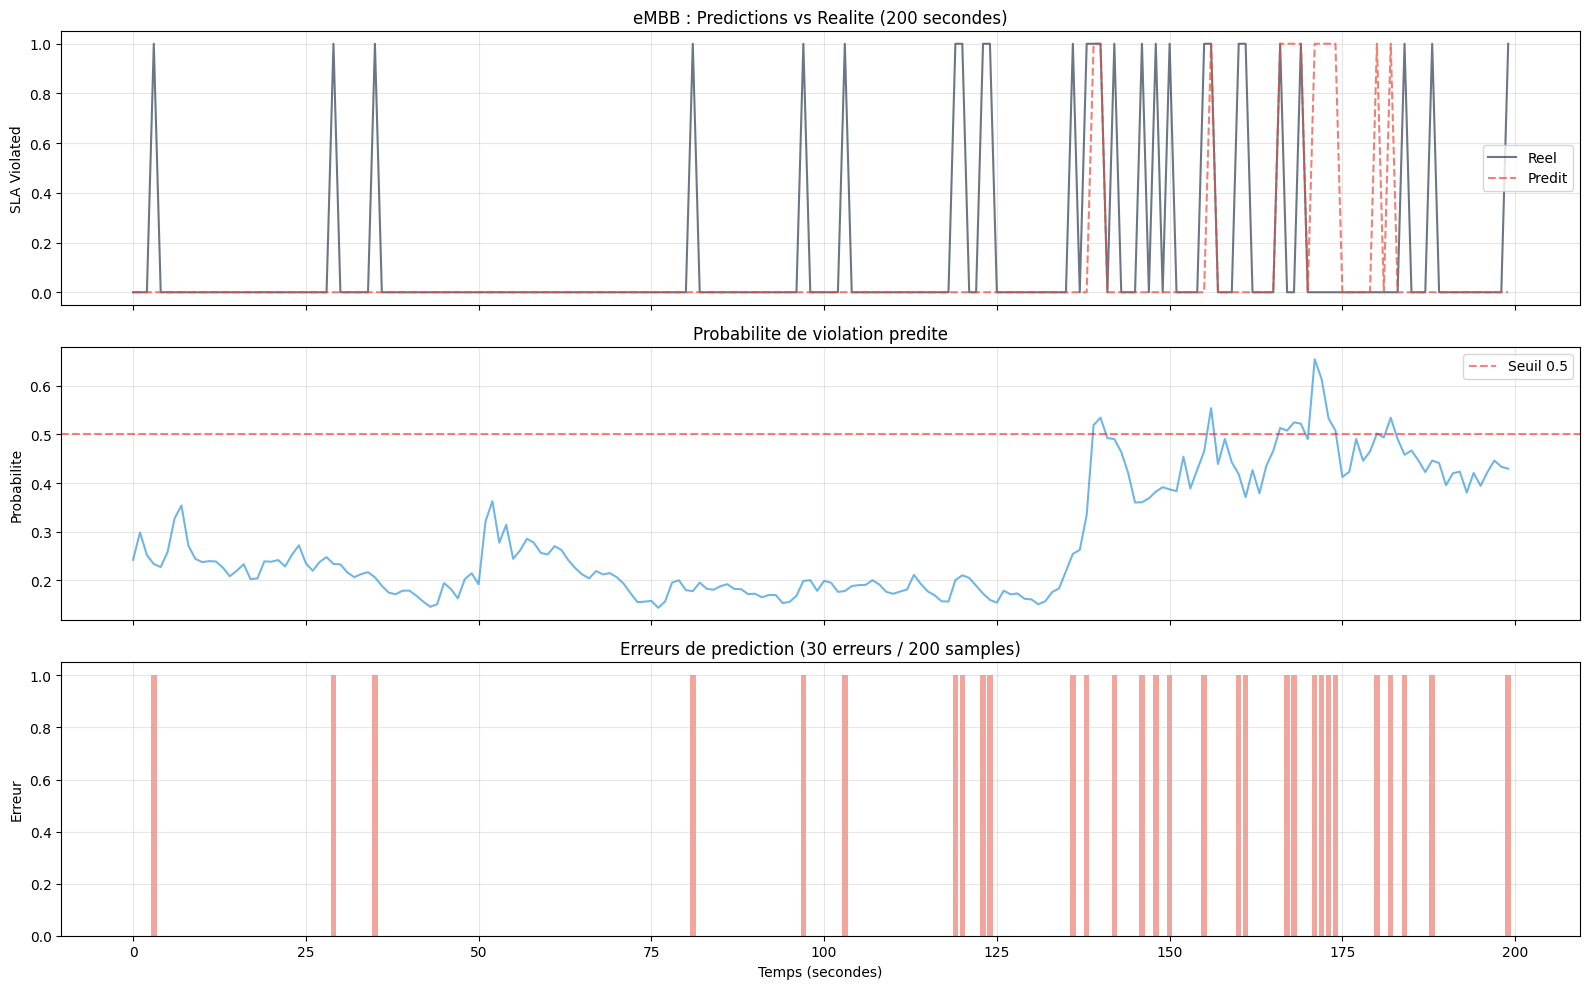

In [26]:
# --- Analyse temporelle des predictions sur eMBB ---
# Visualiser les predictions vs realite sur une fenetre de 200 secondes

embb_mask = slice_labels_test == 'eMBB'
if embb_mask.sum() > 200:
    window = slice(0, 200)
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(y_test[embb_mask][window], label='Reel', color='#2c3e50', alpha=0.7)
    axes[0].plot(y_pred[embb_mask][window], label='Predit', color='#e74c3c', alpha=0.7, linestyle='--')
    axes[0].set_ylabel('SLA Violated')
    axes[0].set_title('eMBB : Predictions vs Realite (200 secondes)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(y_pred_proba[embb_mask][window], color='#3498db', alpha=0.7)
    axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Seuil 0.5')
    axes[1].set_ylabel('Probabilite')
    axes[1].set_title('Probabilite de violation predite')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Erreurs
    errors = np.abs(y_test[embb_mask][window] - y_pred[embb_mask][window])
    axes[2].bar(range(len(errors)), errors, color='#e74c3c', alpha=0.5)
    axes[2].set_ylabel('Erreur')
    axes[2].set_xlabel('Temps (secondes)')
    axes[2].set_title(f'Erreurs de prediction ({errors.sum():.0f} erreurs / {len(errors)} samples)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'embb_temporal_analysis.png'), dpi=150)
    plt.show()

In [27]:
# --- Sauvegarde du modele PyTorch ---
model_path = os.path.join(OUTPUT_DIR, 'lstm_approach_a.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'n_features': n_features,
    'lookback': LOOKBACK,
    'history': history,
}, model_path)
print(f'Modele sauvegarde : {model_path}')

# Sauvegarder le scaler pour inference future
import pickle
scaler_path = os.path.join(OUTPUT_DIR, 'scaler_approach_a.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler sauvegarde : {scaler_path}')

# Resume final
print('\n' + '='*60)
print('RESUME - APPROCHE A (M/M/1) - PyTorch LSTM')
print('='*60)
print(f'Dataset       : {len(df):,} lignes')
print(f'Features      : {n_features}')
print(f'Lookback      : {LOOKBACK}s')
print(f'Train samples : {len(X_train):,}')
print(f'Test samples  : {len(X_test):,}')
print(f'F1-score      : {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC       : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'Epochs        : {len(history["train_loss"])}')
print(f'Device        : {device}')
print('='*60)

Modele sauvegarde : C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\output\lstm_approach_a.pt
Scaler sauvegarde : C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\output\scaler_approach_a.pkl

RESUME - APPROCHE A (M/M/1) - PyTorch LSTM
Dataset       : 111,040 lignes
Features      : 20
Lookback      : 30s
Train samples : 88,713
Test samples  : 22,117
F1-score      : 0.8606
AUC-ROC       : 0.9710
Epochs        : 50
Device        : cpu
